<a href="https://colab.research.google.com/github/Aditi0912dec/FEDGMMINT/blob/main/FedGMMinit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.datasets import load_digits
from sklearn.ensemble import RandomForestClassifier
from sklearn.mixture import GaussianMixture
from tensorflow.keras.datasets import mnist

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD
from sklearn.neural_network import MLPClassifier
from keras import models
from tensorflow.keras.utils import to_categorical
import time

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
!pip install extra_keras_datasets

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [ ]:
from extra_keras_datasets import emnist

# get the dataset

In [ ]:
def getdataset():


    (X_train,y_train),( X_test,y_test) = emnist.load_data(type="letters")
    y_train = y_train-1
    y_test = y_test-1

    X_train = X_train.reshape((X_train.shape[0],-1))# converting to 1D array

    X_test = X_test.reshape((X_test.shape[0], -1))

    return X_train, X_test, y_train, y_test

# data processing

In [ ]:
#Scale Pixels
def prep_pixels(trainX, testX):
	# convert from integers to floats
	train_norm = trainX.astype('float32')
	test_norm = testX.astype('float32')

	# normalize to range 0-1
	train_norm = train_norm / 255.0
	test_norm = test_norm / 255.0

	return train_norm, test_norm


# 2NN model

In [ ]:
def get_2NN_model(trainX):
  input_size=trainX.shape[1]

  model = Sequential([
                    Dense(200, input_shape=(input_size,), activation="relu"),
                    Dense(200, activation='relu'),
                    Dense(26, activation="softmax")])
  return model

# CNN model

In [ ]:
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Flatten
from tensorflow.keras.models import Sequential

In [ ]:
# define cnn model. # parameters not matching
def get_CNN_model():
  model = Sequential()
  model.add(Conv2D(32, (5, 5), activation='relu', kernel_initializer='he_uniform', input_shape=(28, 28, 1)))

  model.add(MaxPooling2D((2,2)))
  model.add(Conv2D(64, (5, 5), activation='relu', kernel_initializer='he_uniform'))

  model.add(MaxPooling2D((2,2)))
  model.add(Flatten())
  #model.add(Dense(1024, activation='relu', kernel_initializer='he_uniform'))
  model.add(Dense(512, activation='relu', kernel_initializer='he_uniform'))
  model.add(Dense(26, activation='softmax'))
	# compile model
	#opt = SGD(learning_rate=0.01, momentum=0.9)
  model.compile(optimizer='SGD', loss='categorical_crossentropy', metrics=['accuracy'])
  return model

# non-IID set up

In [ ]:
def get_nid_dataset(trainX_nid,trainY_nid):
  sorted_label_list=[]
  local_xy=[]
  local_xy_nid=[]
  local_shrad_nid=[]
  for i in (((np.unique([trainY_nid])))) :

    _,label = np.where([trainY_nid==i])

    sorted_label_list.append(label)

  sorted_label= np.hstack(sorted_label_list)

  trainY_nid=trainY_nid[sorted_label]

  trainX_nid=trainX_nid[sorted_label]
  trainY_nid= to_categorical(trainY_nid)
  s=0
  client_count=100
  e=624# shrad size
  num_shrads=200
  for i in range(0,num_shrads):
    local_x=trainX_nid[s:e,:]
    local_y=trainY_nid[s:e,:]
    local_shrad_nid.append((local_x,local_y))
    s=e
    e+=624
  j=0
 # rand_index=np.random.shuffle(np.arrange(num_shrads))
  for i in range(0,100):

    local_x1,local_y1=local_shrad_nid[i]
   # print(tf.math.argmax(local_y1,axis=1))
    local_x2,local_y2=local_shrad_nid[i+100]
    #print(tf.math.argmax(local_y2,axis=1))
    local_x=np.vstack((local_x1,local_x2))
    local_y=np.vstack((local_y1,local_y2))
    local_xy.append((local_x,local_y))


  print("non-iid data distribution done ")
  return local_xy

# get local models

In [ ]:
def load_all_models(local_xy,central_model,X,model_name):
  all_models = list()
  n_clients=100
  for client in range(n_clients):

    central_model_weights=central_model.get_weights()#get weights of the central model as the initialliser for all the local model.
    # To keep the initial weight of all the local models same.
    local_x, local_y = local_xy[client]
    if model_name=='2NN':
      local_model=get_2NN_model(X)
      epochs=1
    else:
      local_model=get_CNN_model()
      local_x = local_x.reshape((local_x.shape[0], 28, 28, 1))
      epochs=5

    local_model.compile(optimizer='SGD',loss= 'categorical_crossentropy', metrics=['accuracy'])

    local_model.set_weights(central_model_weights)
    #local_y=to_categorical(local_y)

    local_model.fit(x=local_x, y=local_y, batch_size=10, epochs=epochs, verbose=0)# training local data by local clients

    all_models.append(local_model)

  print("client model creation and updation of central model weights by local datasets by local clients done")
  return all_models

# ensemble weights

In [ ]:
def model_weight_ensemble(members,central_model):

	# determine how many layers need to be averaged

	n_layers = len(members[0].get_weights())
	# create an set of average model weights
	avg_model_weights = list()
	for layer in range(n_layers):
		#print(layer)
		# collect this layer from each model
		layer_weights = np.array([model.get_weights()[layer] for model in members])
		# weighted average of weights for this layer
		avg_layer_weights = np.average(layer_weights, axis=0)
		# store average layer weights
		avg_model_weights.append(avg_layer_weights)

	#central_model.compile(loss='categorical_crossentropy', optimizer='SGD', metrics=['accuracy'])
	central_model.set_weights(avg_model_weights)# setting the weights of the central model as the average weight of the local model
	print("ensemble of weights done")
	return central_model

# testing

In [ ]:
def test_central_model(testX,testY,central_model,local_xy,cycle,model_name):
   testY=to_categorical(testY)
   accuracy=[]
   if(model_name=="CNN"):
     testX=testX.reshape((testX.shape[0],28,28,1))

   k=1
   test_eval = central_model.evaluate(testX, testY, verbose=0)

   while(k<=cycle):
     accuracy.append(round(test_eval[1],2))
     print("cycle "+str(k)+" accuracy : " +str(round(test_eval[1],2)))
     members=load_all_models(local_xy,central_model,testX,model_name)
     central_model = model_weight_ensemble(members,central_model)
     k=k+1
     test_eval = central_model.evaluate(testX, testY, verbose=0)
  # print(" round "+str(k)+" accuracy : " +str(round(test_eval[1],2)))
   return accuracy


#GMM

In [ ]:
import tensorflow as tf

# create GMM for each client per label
# there are 100 clients each having 10 distinct label in their dataset (IID)
# thus the number of GMM per client is 10
# thus total number of GMM is 100

def get_gmm_noniid(local_Xy):
  print("in gmm non iiid")
  n_comp = 3 # placeholder
  n_clients=100
  gmm_list = []

  for i in range(100) :

    #gmm_i = GaussianMixture(n_components=n_comp)

    local_X, local_y = local_Xy[i]
    local_y=tf.math.argmax(local_y,axis=1)
    label=np.unique(local_y)
    #ind_digits=[]
    #start=i/20
    #end=start+5
    #label=[start,end]
    for j in label :
      _, ind_i = np.where([local_y==j])# index of samples for  each label
      #ind_digits.append(ind_i)
      gmm_i = GaussianMixture(n_components=n_comp)
      gmm_i.fit(local_X[ind_i])# fitting a GMM for each label
      #local_gmm_list.append(gmm_i)
      gmm_list.append((gmm_i,j))
    #print(len(local_gmm_list))
   # gmm_list.append(local_gmm_list)
    #print(len(gmm_list[i]))
  print( ' GMM fit done')

  return gmm_list


# sampling

In [ ]:

def sampling(gmm_list):
  n_samp = 20

  syn_X_list = []
  syn_y_list = []
  n_clients=100

  for i in range(0,len(gmm_list)):# I have changed this to 100 from 26
    gmm,j = gmm_list[i]
    syn_X1,_ = gmm.sample(n_samp)
    syn_y1 = np.full(n_samp,j)
      #syn_X1=syn_X1.reshape((28,28))
    syn_X_list.append(syn_X1)
    syn_y_list.append(syn_y1)

  syn_X = np.concatenate(syn_X_list)
  syn_y = np.concatenate(syn_y_list)

 # print (syn_X.shape,syn_y.shape)
  print("sampling done ")
  return syn_X,syn_y

# shuffling of the dataset

In [ ]:
from sklearn.utils import shuffle
def shuffle_dataset(trainX,trainY):
  # number of datapoints [0,1,2,.....,n]
  no_dataPoints_train = np.arange(0,trainX.shape[0]) # 50000
  #no_dataPoints_test = np.arange(0,testX.shape[0])   # 10000
  #random.seed(4)
  # random shuffling
  np.random.shuffle(no_dataPoints_train)
  #np.random.shuffle(no_dataPoints_test)

  # reshuffled original train data
  X_train = trainX[no_dataPoints_train]
  y_train = trainY[no_dataPoints_train]

  # reshuffled original test data
  #X_test = testX[no_dataPoints_test]
  #y_test = testY[no_dataPoints_test]


  print("data shuffling done")
  return X_train,y_train

# one shot testing

In [ ]:
def one_shot_testing(testX,testY,one_shot_model,model_name):
   testY=to_categorical(testY)
   if(model_name=="CNN"):
     testX=testX.reshape((testX.shape[0],28,28,1))



   score= one_shot_model.evaluate(testX, testY, verbose=0)

   return score[1]


# Initalisation

In [ ]:
trainX, testX, trainY, testY=getdataset()
trainX_tmp, testX_tmp, trainY_tmp, testY_tmp=trainX, testX, trainY, testY
print(trainX.shape,testX.shape,trainY.shape,testY.shape)

743915520/743900280 [==============================] - 29s 0us/step


(124800, 784) (20800, 784) (124800,) (20800,)


In [ ]:
trainX, testX=prep_pixels(trainX, testX)

In [ ]:
local_xy_nid=get_nid_dataset(trainX,trainY)

non-iid data distribution done 


In [ ]:
from google.colab import drive


drive.mount('/content/gdrive/', force_remount=True)


Mounted at /content/gdrive/


In [ ]:
import pickle

In [ ]:




#Save the variable
pickle.dump(local_xy_id, open("/content/gdrive/MyDrive/noniid.dat", "wb"))



In [ ]:
local_xy_id= pickle.load(open("/content/gdrive/MyDrive/noniid.dat", "rb"))

# pre requisit

In [ ]:
gmm_list=get_gmm_noniid(local_xy_nid)# get the gmm

in gmm non iiid
 GMM fit done


In [ ]:

syn_X,syn_y = sampling(gmm_list) # sampled points


sampling done 


In [ ]:
syn_X,syn_y=shuffle_dataset(syn_X,syn_y) #shuffling the dataset

data shuffling done


In [ ]:
print(syn_X.shape,syn_y.shape)

(2520, 784) (2520,)


In [ ]:

syn_y=to_categorical(syn_y)


# GMM +MLP

In [ ]:


one_shot_model=get_2NN_model(trainX) # create the model
one_shot_model.summary()

one_shot_model.compile(loss='categorical_crossentropy', optimizer='SGD', metrics=['accuracy'])
one_shot_model.fit(syn_X,syn_y) # train the model
wm=one_shot_model.get_weights()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 200)               157000    
                                                                 
 dense_1 (Dense)             (None, 200)               40200     
                                                                 
 dense_2 (Dense)             (None, 26)                5226      
                                                                 
Total params: 202,426
Trainable params: 202,426
Non-trainable params: 0
_________________________________________________________________
79/79 [==============================] - 1s 3ms/step - loss: 3.2056 - accuracy: 0.0710


In [ ]:

accuracy_1=one_shot_testing(testX,testY,one_shot_model,'2NN') # testing the model

In [ ]:
print("GMM accuracy in one round for MLP is: "+str(accuracy_1))

GMM accuracy in one round for MLP is: 0.11581730842590332


# MLP+ GMM +FedAvg

In [ ]:
rounds=10

In [ ]:
fedavg_central_model=get_2NN_model(trainX)


In [ ]:
fedavg_central_model.compile(loss='categorical_crossentropy', optimizer='SGD', metrics=['accuracy'])

fedavg_central_model.set_weights(wm)



In [ ]:
# get the local models
members=load_all_models(local_xy_nid,fedavg_central_model,trainX,"2NN")

client model creation and updation of central model weights by local datasets by local clients done


In [ ]:
fedavg_central_model=model_weight_ensemble(members,fedavg_central_model)

ensemble of weights done


In [ ]:
accuracy_gmm_fed=test_central_model(testX,testY,fedavg_central_model,local_xy_nid,rounds,'2NN')


cycle 1 accuracy : 0.12
client model creation and updation of central model weights by local datasets by local clients done
ensemble of weights done
cycle 2 accuracy : 0.14
client model creation and updation of central model weights by local datasets by local clients done
ensemble of weights done
cycle 3 accuracy : 0.17
client model creation and updation of central model weights by local datasets by local clients done
ensemble of weights done
cycle 4 accuracy : 0.19
client model creation and updation of central model weights by local datasets by local clients done
ensemble of weights done
cycle 5 accuracy : 0.22
client model creation and updation of central model weights by local datasets by local clients done
ensemble of weights done
cycle 6 accuracy : 0.23
client model creation and updation of central model weights by local datasets by local clients done
ensemble of weights done
cycle 7 accuracy : 0.25
client model creation and updation of central model weights by local datasets by l

# Fedavg + MLP

In [ ]:
fedavg_central_model=get_2NN_model(trainX)


In [ ]:
fedavg_central_model.compile(loss='categorical_crossentropy', optimizer='SGD', metrics=['accuracy'])


In [ ]:
# get the local models
members=load_all_models(local_xy_nid,fedavg_central_model,trainX,"2NN")

client model creation and updation of central model weights by local datasets by local clients done


In [ ]:
fedavg_central_model=model_weight_ensemble(members,fedavg_central_model)

ensemble of weights done


In [ ]:
accuracy_fed=test_central_model(testX,testY,fedavg_central_model,local_xy_nid,rounds,'2NN')


cycle 1 accuracy : 0.05
client model creation and updation of central model weights by local datasets by local clients done
ensemble of weights done
cycle 2 accuracy : 0.06
client model creation and updation of central model weights by local datasets by local clients done
ensemble of weights done
cycle 3 accuracy : 0.07
client model creation and updation of central model weights by local datasets by local clients done
ensemble of weights done
cycle 4 accuracy : 0.08
client model creation and updation of central model weights by local datasets by local clients done
ensemble of weights done
cycle 5 accuracy : 0.1
client model creation and updation of central model weights by local datasets by local clients done
ensemble of weights done
cycle 6 accuracy : 0.12
client model creation and updation of central model weights by local datasets by local clients done
ensemble of weights done
cycle 7 accuracy : 0.14
client model creation and updation of central model weights by local datasets by lo

# comparison

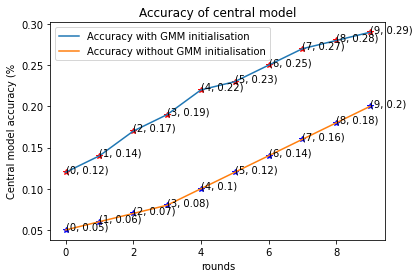

In [ ]:
import matplotlib.pyplot as plt
# x axis values
x = np.arange(10).tolist()
# corresponding y axis values
y1= accuracy_gmm_fed
y2= accuracy_fed

# plotting the points
plt.plot(x, y1, 'r*')
plt.title('Accuracy of central model')
plt.plot(x, y1,label='Accuracy with GMM initialisation')

plt.rcParams["figure.figsize"] = [7.50,5.50]
plt.rcParams["figure.autolayout"] = True
for i, j in zip(x, y1):
   plt.text(i, j, '({}, {})'.format(i, j))

plt.plot(x, y2, 'b*')
plt.plot(x, y2,label='Accuracy without GMM initialisation')
for i, j in zip(x, y2):
   plt.text(i, j, '({}, {})'.format(i, j))

plt.legend()
# naming the x axis
plt.xlabel('rounds')
# naming the y axis
plt.ylabel('Central model accuracy (%')
# function to show the plot
plt.show()

# GMM + CNN

In [ ]:


one_shot_model=get_CNN_model() # create the model
one_shot_model.summary()

one_shot_model.compile(loss='categorical_crossentropy', optimizer='SGD', metrics=['accuracy'])
syn_X=syn_X.reshape((syn_X.shape[0],28,28,1))

one_shot_model.fit(syn_X,syn_y) # train the model
wc=one_shot_model.get_weights()


Model: "sequential_2203"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 24, 24, 32)        832       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 12, 12, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 8, 8, 64)          51264     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 4, 4, 64)         0         
 2D)                                                             
                                                                 
 flatten (Flatten)           (None, 1024)              0         
                                                                 
 dense_6609 (Dense)          (None, 512)           

In [ ]:
accuracy_2=one_shot_testing(testX,testY,one_shot_model,'CNN') # testing the model

In [ ]:
print("GMM accuracy in one round is FOR CNN: "+str(accuracy_2))

GMM accuracy in one round is FOR CNN: 0.37889423966407776


# CNN +GMM +FedAvg

In [ ]:
fedavg_central_model=get_CNN_model()


In [ ]:
fedavg_central_model.compile(loss='categorical_crossentropy', optimizer='SGD', metrics=['accuracy'])

fedavg_central_model.set_weights(wc)



In [ ]:
# get the local models
members=load_all_models(local_xy_nid,fedavg_central_model,trainX,"CNN")

client model creation and updation of central model weights by local datasets by local clients done


In [ ]:
fedavg_central_model=model_weight_ensemble(members,fedavg_central_model)

ensemble of weights done


In [ ]:
accuracy_gmm_fed=test_central_model(testX,testY,fedavg_central_model,local_xy_nid,rounds,'CNN')


cycle 1 accuracy : 0.49
client model creation and updation of central model weights by local datasets by local clients done
ensemble of weights done
cycle 2 accuracy : 0.52


# CNN+FedAvg

In [ ]:
fedavg_central_model=get_CNN_model()


In [ ]:
fedavg_central_model.compile(loss='categorical_crossentropy', optimizer='SGD', metrics=['accuracy'])


In [ ]:
# get the local models
members=load_all_models(local_xy_nid,fedavg_central_model,trainX,"CNN")

In [ ]:
fedavg_central_model=model_weight_ensemble(members,fedavg_central_model)

In [ ]:
accuracy_gmm_fed=test_central_model(testX,testY,fedavg_central_model,local_xy_nid,rounds,'CNN')


In [ ]:
accuracy_fed=test_central_model(testX,testY,fedavg_central_model,local_xy_nid,rounds,'CNN')


# comparison

In [ ]:
# x axis values
import matplotlib.pyplot as plt
import numpy as np
x = np.arange(10).tolist()
# corresponding y axis values
y1= [0.48,0.51,0.53,0.54,0.55,0.55,0.56,0.57,0.57,0.58]
y2= [0.04,0.06,0.08,0.11,0.15,0.18,0.21,0.21,0.22,0.22]

# plotting the points
plt.plot(x, y1, 'r*')
plt.title('Accuracy of central model')
plt.plot(x, y1,label='Accuracy with GMM initialisation')

plt.rcParams["figure.figsize"] = [7.50,5.50]
plt.rcParams["figure.autolayout"] = True
for i, j in zip(x, y1):
   plt.text(i, j, '({}, {})'.format(i, j))
# giving a title to my graph
#plt.title('My first graph!')
#y=[100,93,95,92,97,97,98,98,92,89]
plt.plot(x, y2, 'b*')
plt.plot(x, y2,label='Accuracy without GMM initialisation')
for i, j in zip(x, y2):
   plt.text(i, j, '({}, {})'.format(i, j))

plt.legend()
# naming the x axis
plt.xlabel('rounds')
# naming the y axis
plt.ylabel('Central model accuracy (%')
# function to show the plot
plt.show()